# Analyzing the Autism Prevalence

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime

Read csv files to Dataframe

In [4]:
# Read Autism prevalance around the world
asd_world = pd.read_csv("../data/autism_prevalence_studies.csv")
asd_world.head()

,Author,Title,Year Published,Country,Area(s),Age Range,Study Years,Case Identification Method,Case Criterion,Sample Size,...,Diagnosis Age Range (months),Diagnosis Mean Age (months),Diagnosis Median Age (months),IQ Score <70 (%),Adaptive Score <70 (%),Non-Verbal or Minimally Verbal (%),Percentage of Individual Co-occurring Conditions,Autism Types Included,Link to Publication,CDC Calculated Values
0,Lotter,Epidemiology of Autistic Conditions in Young C...,1966,England,County of Middlesex,8 to 10,1964,survey (mail); health records,Kanner,78000.0,...,NaN,NaN,NaN,84.0,NaN,59.0,NaN,autistic conditions,https://link.springer.com/article/10.1007/BF00...,IQ Score <70 (%); CI
1,Treffert,Epidemiology of infantile Autism,1970,USA,Wisconsin,2 to 12,1962-1967,health records,Kanner,899750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,classic infantile autism,https://www.ncbi.nlm.nih.gov/pubmed/5436867,CI
2,Brask,A Prevalence investigation of Childhood Psychoses,1972,Denmark,Åarhus County,2 to 14,1962,health records; service provider records,clinical interpretation,46500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,autistic syndrome,NaN,CI
3,"Wing, et al.",The prevalence of early childhood autism: comp...,1976,England,Camberwall,5 to 14,1974,registry; survey (unspecified),clinical interpretation,25000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,early childhood autism,https://pubmed.ncbi.nlm.nih.gov/935299/,CI
4,"Wing, et al.",Severe impairments of social interaction and a...,1979,England,Camberwell,0 to 14,1970,registry; service provider records,Kanner; clinical interpretation,35000.0,...,NaN,NaN,NaN,70.0,NaN,59.0,0 (Down syndrome),autism,https://www.ncbi.nlm.nih.gov/pubmed/155684,IQ Score <70 (%); CI


In [5]:
asd_world.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 26 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Author                                            207 non-null    object 
 1   Title                                             207 non-null    object 
 2   Year Published                                    207 non-null    int64  
 3   Country                                           207 non-null    object 
 4   Area(s)                                           202 non-null    object 
 5   Age Range                                         202 non-null    object 
 6   Study Years                                       185 non-null    object 
 7   Case Identification Method                        207 non-null    object 
 8   Case Criterion                                    207 non-null    object 
 9   Sample Size          

In [33]:
# Filter Countries with total Sample size
asd_world_sample =  asd_world.groupby('Country')['Sample Size'].sum().sort_values(ascending=False).reset_index()
asd_world_sample.head()

,Country,Sample Size
0,USA,79669014.0
1,South Korea,51584604.0
2,England,8063035.0
3,Germany,6679616.0
4,Taiwan,5690743.0


In [7]:
# Filter Countries with total cases
asd_world_count =  asd_world.groupby('Country')['Number of Cases'].sum().sort_values(ascending=False).reset_index()

In [8]:
# Merge Sample and Number of cases column
asd_world_count_sample = pd.merge(asd_world_sample, asd_world_count, on = 'Country', how = 'left')
asd_world_count_sample = asd_world_count_sample.sort_values("Number of Cases", ascending=False)
asd_world_count_sample
asd_world_count_sample_percentage = asd_world_count_sample
asd_world_count_sample_percentage["Percentage"] = round(asd_world_count_sample["Number of Cases"]/ asd_world_count_sample["Sample Size"]*100,2)
asd_world_count_sample_percentage
asd_world_count_sample_percentage_top_5 = asd_world_count_sample_percentage.head(5)
asd_world_count_sample_percentage_top_5

,Country,Sample Size,Number of Cases,Percentage
0,USA,79669014.0,745934.0,0.94
2,England,8063035.0,121913.0,1.51
5,Sweden,5025798.0,43888.0,0.87
6,Korea,4989351.0,35529.0,0.71
7,Canada,4536704.0,23330.0,0.51


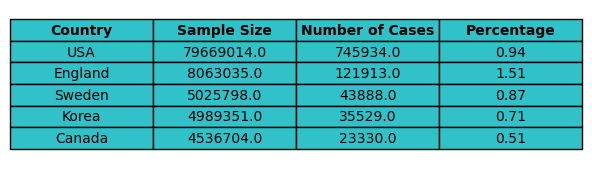

In [9]:
# DataFrame
df = asd_world_count_sample_percentage_top_5

# Convert to list of lists
data = df.values.tolist()
col_labels = df.columns.tolist()

# Create figure
fig, ax = plt.subplots(figsize=(6, 1.8))

# Turn off axes
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(
    cellText=data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# color all cells
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('#30C1C9')   # aqua background
    cell.set_text_props(color='black')


# bold header
for key, cell in table.get_celld().items():
    if key[0] == 0:  # header row
        cell.set_text_props(weight='bold')
       

plt.tight_layout()
plt.savefig("table_top5.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

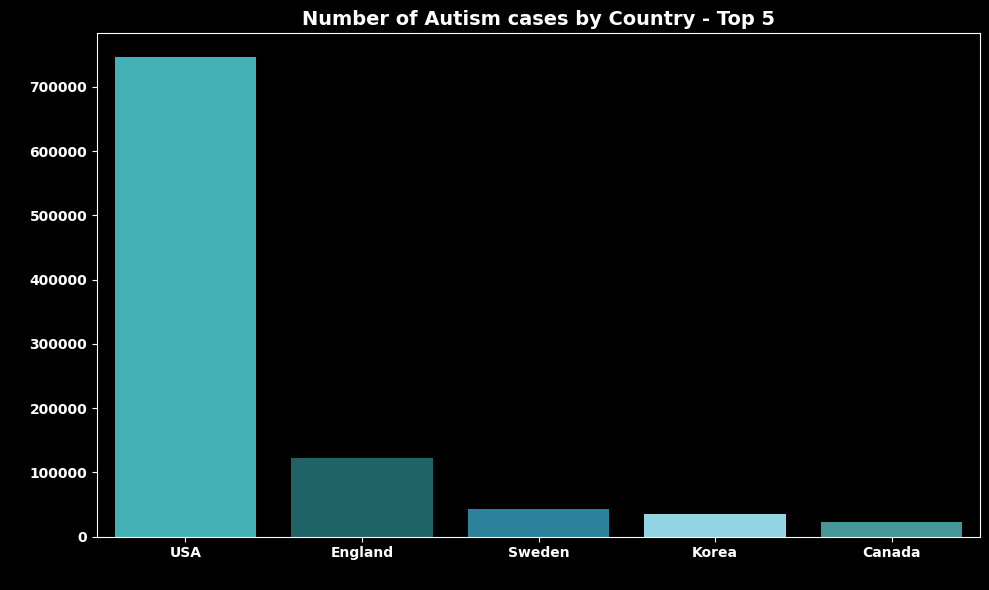

In [10]:
# Create bar chart
plt.figure(figsize=(10, 6), facecolor="black")

# Custom colors
color = ['#30C1C9','#136E73', '#178DAE', '#84DCF4', '#38A2A7']

# Bar chart with Seaborn palette
sns.barplot(
    data=asd_world_count_sample_percentage_top_5,
    x="Country",
    y="Number of Cases",
    palette = color, hue = "Country",legend=False
)

plt.title('Number of Autism cases by Country - Top 5',
          fontsize=14, fontweight='bold', color="white")
#plt.xlabel('Country', fontweight='bold', color="white")
#plt.ylabel('Number of Cases', fontweight='bold', color="white")

# Make axes, ticks, and spines white
ax = plt.gca()
ax.set_facecolor("black")
ax = plt.gca()

#ax.xaxis.label.set_color("white")
#ax.yaxis.label.set_color("white")

# Tick labels (x and y)
ax.tick_params(axis='x', colors='white', labelsize=10)
ax.tick_params(axis='y', colors='white', labelsize=10)

# Force-set tick label text objects (sometimes needed in dark themes)
for tick in ax.get_xticklabels():
    tick.set_color("white")
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_color("white")
    tick.set_fontweight("bold")

# Spines
for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.savefig("cases_by_country_top5", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

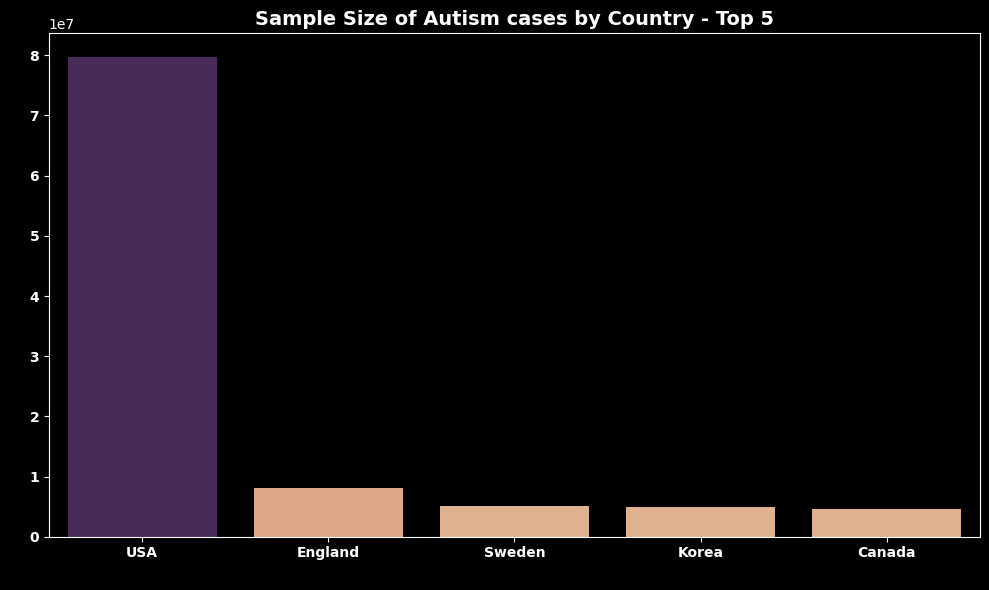

In [11]:
# Create bar chart
plt.figure(figsize=(10, 6), facecolor="black")

# Bar chart with Seaborn palette
sns.barplot(
    data=asd_world_count_sample_percentage_top_5,
    x="Country",
    y="Sample Size",
    palette="flare", hue = "Sample Size", legend=False
)

plt.title('Sample Size of Autism cases by Country - Top 5',
          fontsize=14, fontweight='bold', color="white")
#plt.xlabel('Country', fontweight='bold', color="white")
#plt.ylabel('Number of Cases', fontweight='bold', color="white")

# Make axes, ticks, and spines white
ax = plt.gca()
ax.set_facecolor("black")
ax = plt.gca()
#ax.xaxis.label.set_color("white")
#ax.yaxis.label.set_color("white")

# Tick labels (x and y)
ax.tick_params(axis='x', colors='white', labelsize=10)
ax.tick_params(axis='y', colors='white', labelsize=10)

# Force-set tick label text objects (sometimes needed in dark themes)
for tick in ax.get_xticklabels():
    tick.set_color("white")
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_color("white")
    tick.set_fontweight("bold")

# Spines
for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.savefig("samplesize_by_country_top5", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [12]:
asd_world_count_sample_percentage_bottom_5 = asd_world_count_sample_percentage.tail(7).dropna()
asd_world_count_sample_percentage_bottom_5

,Country,Sample Size,Number of Cases,Percentage
37,Indonesia,5120.0,6.0,0.12
36,Bangladesh,5286.0,4.0,0.08
41,Brazil,1470.0,4.0,0.27
46,Sri Lanka,374.0,4.0,1.07
44,United Arab Emirates,694.0,2.0,0.29


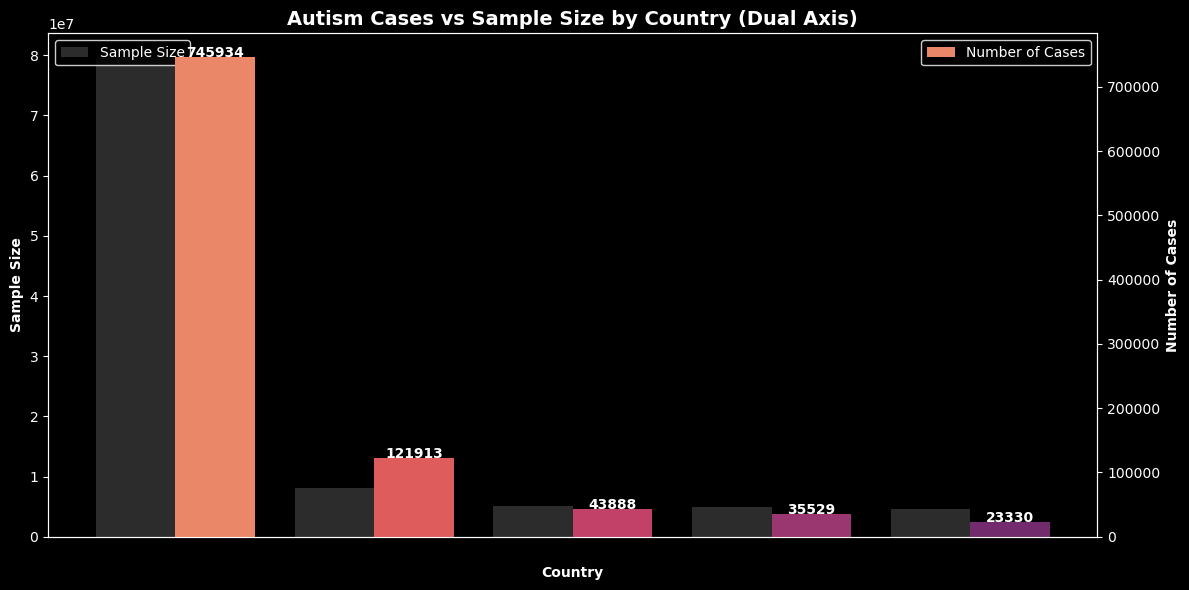

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Your DataFrame is already defined as: ---
# asd_world_count_sample_top_5

plt.figure(figsize=(12, 6), facecolor="black")

ax1 = plt.gca()
x = np.arange(len(asd_world_count_sample_percentage_top_5))
width = 0.4

# --- BAR 1: Sample Size (Left Axis) ---
bars1 = ax1.bar(
    x - width/2,
   asd_world_count_sample_percentage_top_5["Sample Size"],
    width,
    color="gray",
    alpha=0.35,
    label="Sample Size"
)

# --- SECOND AXIS ---
ax2 = ax1.twinx()

# --- BAR 2: Number of Cases (Right Axis) ---
bars2 = ax2.bar(
    x + width/2,
    asd_world_count_sample_percentage_top_5["Number of Cases"],
    width,
    color=sns.color_palette("flare", len(asd_world_count_sample_percentage_top_5)),
    label="Number of Cases"
)

# --- TITLES & LABELS ---
plt.title(
    "Autism Cases vs Sample Size by Country (Dual Axis)",
    fontsize=14, fontweight="bold", color="white"
)

ax1.set_xlabel("Country", fontweight="bold", color="white")
ax1.set_ylabel("Sample Size", fontweight="bold", color="white")
ax2.set_ylabel("Number of Cases", fontweight="bold", color="white")

# --- X‑TICKS ---
plt.xticks(
    x,
    asd_world_count_sample_percentage_top_5["Country"],
    color="white",
    fontweight="bold",
    rotation=20
)


# --- Y‑TICKS ---
ax1.tick_params(axis='y', colors='white')
ax2.tick_params(axis='y', colors='white')

# --- SPINES ---
for spine in ax1.spines.values():
    spine.set_color("white")
for spine in ax2.spines.values():
    spine.set_color("white")

ax1.set_facecolor("black")
ax2.set_facecolor("black")

# --- VALUE LABELS ON CASE BARS ---
for bar in bars2:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{int(height)}",
        ha="center",
        color="white",
        fontweight="bold",
        fontsize=10
    )

# --- LEGENDS ---
ax1.legend(loc="upper left", facecolor="black", edgecolor="white", labelcolor="white")
ax2.legend(loc="upper right", facecolor="black", edgecolor="white", labelcolor="white")

plt.tight_layout()
plt.savefig("dual_axis_cases_sample_top5", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

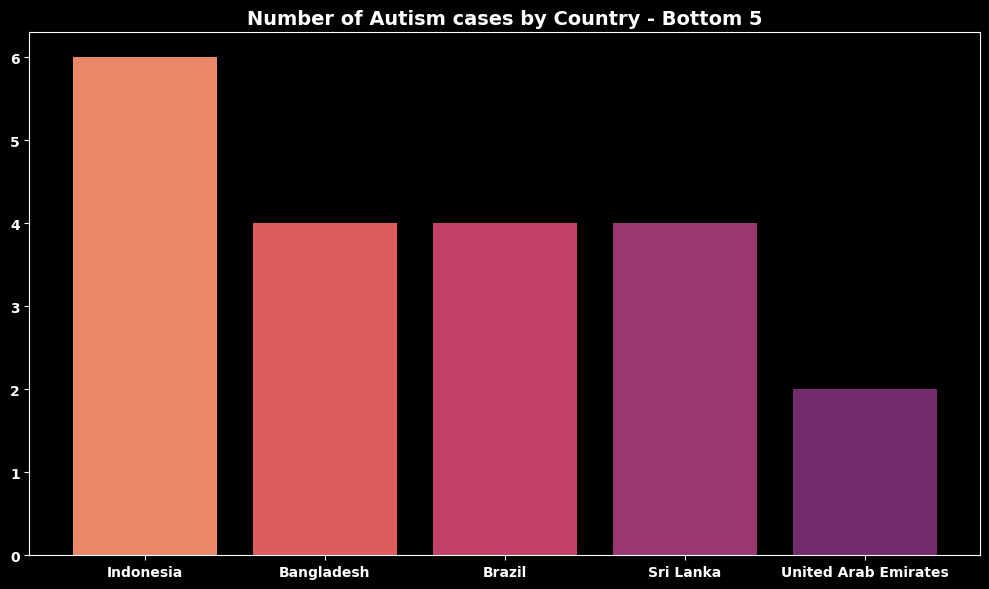

In [14]:
# Create bar chart for Number of Cases by Country
plt.figure(figsize=(10, 6), facecolor="black")

# Bar chart with Seaborn palette
plt.bar(
   asd_world_count_sample_percentage_bottom_5['Country'],
    asd_world_count_sample_percentage_bottom_5['Number of Cases'],
    color=sns.color_palette('flare', len(asd_world_count_sample_percentage_bottom_5))
)

plt.title('Number of Autism cases by Country - Bottom 5',
          fontsize=14, fontweight='bold', color="white")
#plt.xlabel('Country', fontweight='bold', color="white")
#plt.ylabel('Number of Cases', fontweight='bold', color="white")

# Make axes, ticks, and spines white
ax = plt.gca()
ax.set_facecolor("black")
ax = plt.gca()
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")

# Tick labels (x and y)
ax.tick_params(axis='x', colors='white', labelsize=10)
ax.tick_params(axis='y', colors='white', labelsize=10)

# Force-set tick label text objects (sometimes needed in dark themes)
for tick in ax.get_xticklabels():
    tick.set_color("white")
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_color("white")
    tick.set_fontweight("bold")

# Spines
for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.savefig("cases_by_country_bottom5", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

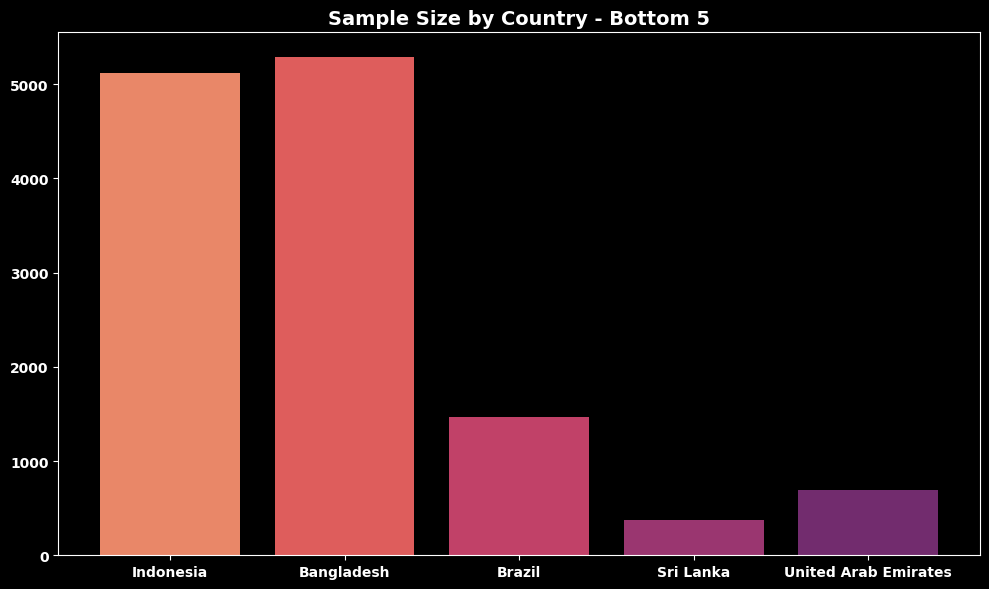

In [15]:
# Create bar chart for Number of Cases by Country
plt.figure(figsize=(10, 6), facecolor="black")

# Bar chart with Seaborn palette
plt.bar(
   asd_world_count_sample_percentage_bottom_5['Country'],
   asd_world_count_sample_percentage_bottom_5['Sample Size'],
    color=sns.color_palette('flare', len(asd_world_count_sample_percentage_bottom_5))
)

plt.title('Sample Size by Country - Bottom 5',
          fontsize=14, fontweight='bold', color="white")
#plt.xlabel('Country', fontweight='bold', color="white")
#plt.ylabel('Number of Cases', fontweight='bold', color="white")

# Make axes, ticks, and spines white
ax = plt.gca()
ax.set_facecolor("black")
ax = plt.gca()
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")

# Tick labels (x and y)
ax.tick_params(axis='x', colors='white', labelsize=10)
ax.tick_params(axis='y', colors='white', labelsize=10)

# Force-set tick label text objects (sometimes needed in dark themes)
for tick in ax.get_xticklabels():
    tick.set_color("white")
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_color("white")
    tick.set_fontweight("bold")

# Spines
for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.savefig("cases_by_country_sample_bottom5", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

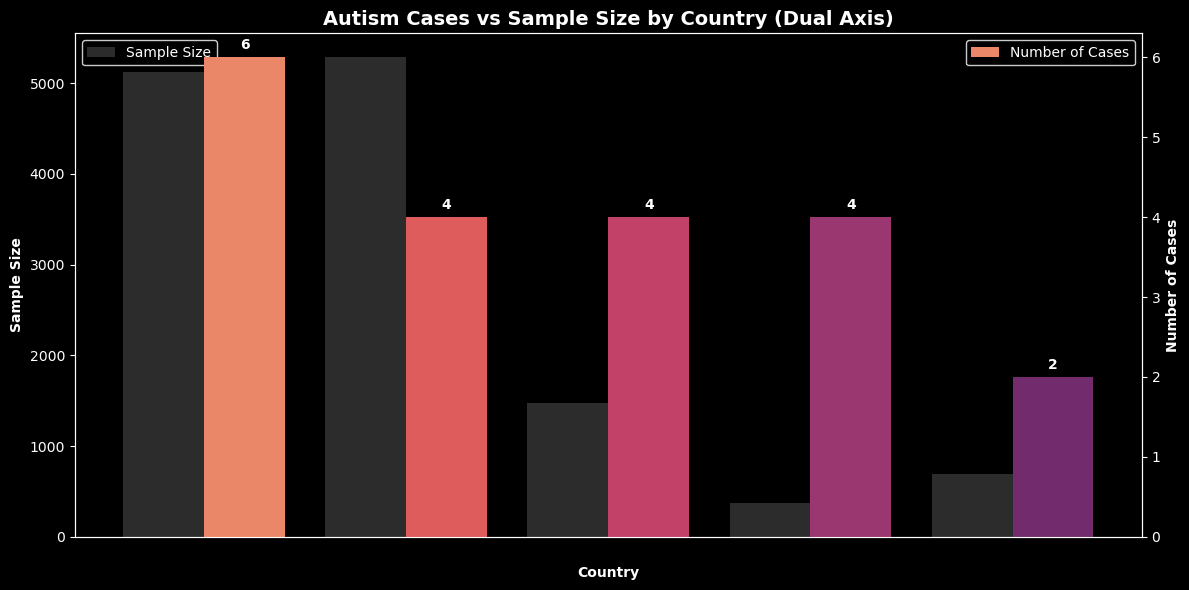

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Your DataFrame is already defined as: ---
# asd_world_count_sample_top_5

plt.figure(figsize=(12, 6), facecolor="black")

ax1 = plt.gca()
x = np.arange(len(asd_world_count_sample_percentage_bottom_5))
width = 0.4

# --- BAR 1: Sample Size (Left Axis) ---
bars1 = ax1.bar(
    x - width/2,
   asd_world_count_sample_percentage_bottom_5["Sample Size"],
    width,
    color="gray",
    alpha=0.35,
    label="Sample Size"
)

# --- SECOND AXIS ---
ax2 = ax1.twinx()

# --- BAR 2: Number of Cases (Right Axis) ---
bars2 = ax2.bar(
    x + width/2,
    asd_world_count_sample_percentage_bottom_5["Number of Cases"],
    width,
    color=sns.color_palette("flare", len(asd_world_count_sample_percentage_bottom_5)),
    label="Number of Cases"
)

# --- TITLES & LABELS ---
plt.title(
    "Autism Cases vs Sample Size by Country (Dual Axis)",
    fontsize=14, fontweight="bold", color="white"
)

ax1.set_xlabel("Country", fontweight="bold", color="white")
ax1.set_ylabel("Sample Size", fontweight="bold", color="white")
ax2.set_ylabel("Number of Cases", fontweight="bold", color="white")

# --- X‑TICKS ---
plt.xticks(
    x,
    asd_world_count_sample_percentage_bottom_5["Country"],
    color="white",
    fontweight="bold",
    rotation=20
)


# --- Y‑TICKS ---
ax1.tick_params(axis='y', colors='white')
ax2.tick_params(axis='y', colors='white')

# --- SPINES ---
for spine in ax1.spines.values():
    spine.set_color("white")
for spine in ax2.spines.values():
    spine.set_color("white")

ax1.set_facecolor("black")
ax2.set_facecolor("black")

# --- VALUE LABELS ON CASE BARS ---
for bar in bars2:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{int(height)}",
        ha="center",
        color="white",
        fontweight="bold",
        fontsize=10
    )

# --- LEGENDS ---
ax1.legend(loc="upper left", facecolor="black", edgecolor="white", labelcolor="white")
ax2.legend(loc="upper right", facecolor="black", edgecolor="white", labelcolor="white")

plt.tight_layout()
plt.savefig("dual_axis_cases_sample", dpi=300, bbox_inches="tight", transparent=True)
plt.show()